In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report
)

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

data = pd.read_csv(
    "horse_colic_normalized.csv",
    delimiter=","
)

df_reduced = pd.read_csv(
    "horse_colic_reduced_encoded.csv",
    delimiter=","
)

target_col = "outcome"

data = data.dropna(subset=[target_col])
df_reduced = df_reduced.dropna(subset=[target_col])

display(data.head())
display(df_reduced.head())

,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,lesion_site,lesion_type,lesion_subtype,cp_data,surgical_lesion
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,11300,0,0,2,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2208,0,0,2,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,0,0,0,1,2
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,2208,0,0,1,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,4300,0,0,2,2


,surgery,hospital_number,rectal_temperature,pulse,respiratory_rate,mucous_membranes,pain,peristalsis,abdominal_distension,abdomen,packed_cell_volume,total_protein,outcome,lesion_site,surgical_lesion
0,2.0,530101,38.5,66.0,28.0,NaN,5.0,4.0,4.0,5.0,45.0,8.4,2.0,11300,2
1,1.0,534817,39.2,88.0,20.0,4.0,3.0,4.0,2.0,2.0,50.0,85.0,3.0,2208,2
2,2.0,530334,38.3,40.0,24.0,3.0,3.0,3.0,1.0,1.0,33.0,6.7,1.0,0,2
3,1.0,5290409,39.1,164.0,84.0,6.0,2.0,4.0,4.0,NaN,48.0,7.2,2.0,2208,1
4,2.0,530255,37.3,104.0,35.0,6.0,NaN,NaN,NaN,NaN,74.0,7.4,2.0,4300,2


In [2]:
X = data.drop(columns=[target_col])
y = data[target_col]

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_reduced = df_reduced.drop(columns=[target_col])
y_reduced = df_reduced[target_col]

X_reduced = X_reduced.fillna(X_reduced.median())

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

In [3]:
clf = MLPClassifier(
    hidden_layer_sizes=(500,),
    max_iter=500,
    random_state=42
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

y_score = clf.predict_proba(X_test)

classes = clf.classes_

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


clf_reduced = MLPClassifier(
    hidden_layer_sizes=(500,),
    max_iter=500,
    random_state=42
)

clf_reduced.fit(
    X_train_reduced,
    y_train_reduced
)

y_pred_reduced = clf_reduced.predict(
    X_test_reduced
)

y_score_reduced = clf_reduced.predict_proba(
    X_test_reduced
)

classes_reduced = clf_reduced.classes_

print("\nAccuracy reduced:",
      accuracy_score(
          y_test_reduced,
          y_pred_reduced
      )
)

print("\nClassification report reduced:")
print(
    classification_report(
        y_test_reduced,
        y_pred_reduced,
        zero_division=0
    )
)

Accuracy: 0.6081081081081081

Classification report:
              precision    recall  f1-score   support

         1.0       0.61      1.00      0.76        45
         2.0       0.00      0.00      0.00        18
         3.0       0.00      0.00      0.00        11

    accuracy                           0.61        74
   macro avg       0.20      0.33      0.25        74
weighted avg       0.37      0.61      0.46        74


Accuracy reduced: 0.20270270270270271

Classification report reduced:
              precision    recall  f1-score   support

         1.0       0.60      0.13      0.22        45
         2.0       0.00      0.00      0.00        18
         3.0       0.14      0.82      0.24        11

    accuracy                           0.20        74
   macro avg       0.25      0.32      0.15        74
weighted avg       0.39      0.20      0.17        74



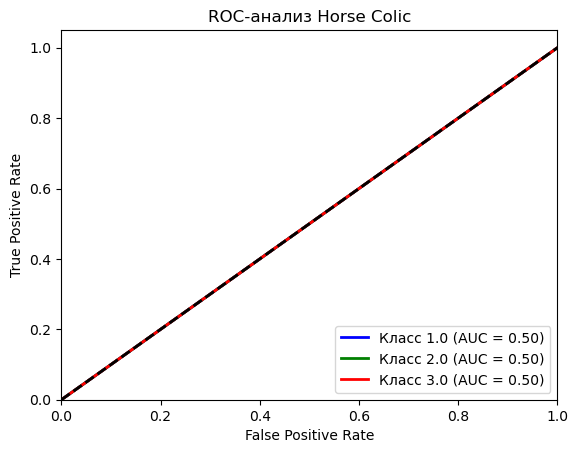

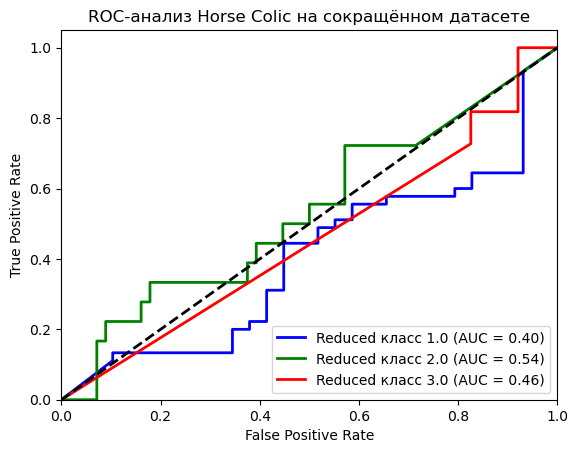

In [7]:
y_test_bin = np.column_stack([
    (y_test == cls).astype(int) for cls in classes
])

fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(classes):
    fpr[i], tpr[i], thresholds = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
colors = ['blue', 'green', 'red']

for i, color in zip(range(len(classes)), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f'Класс {classes[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-анализ Horse Colic')
plt.legend(loc="lower right")
plt.show()

y_test_bin_reduced = np.column_stack([
    (y_test_reduced == cls).astype(int) for cls in classes_reduced
])

fpr_reduced = {}
tpr_reduced = {}
roc_auc_reduced = {}

for i, cls in enumerate(classes_reduced):
    fpr_reduced[i], tpr_reduced[i], thresholds_reduced = roc_curve(
        y_test_bin_reduced[:, i],
        y_score_reduced[:, i]
    )
    roc_auc_reduced[i] = auc(fpr_reduced[i], tpr_reduced[i])

plt.figure()
colors = ['blue', 'green', 'red']

for i, color in zip(range(len(classes_reduced)), colors):
    plt.plot(
        fpr_reduced[i],
        tpr_reduced[i],
        color=color,
        lw=2,
        label=f'Reduced класс {classes_reduced[i]} (AUC = {roc_auc_reduced[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-анализ Horse Colic на сокращённом датасете')
plt.legend(loc="lower right")
plt.show()

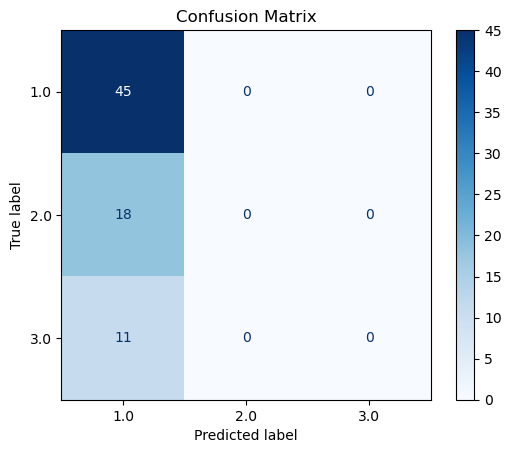

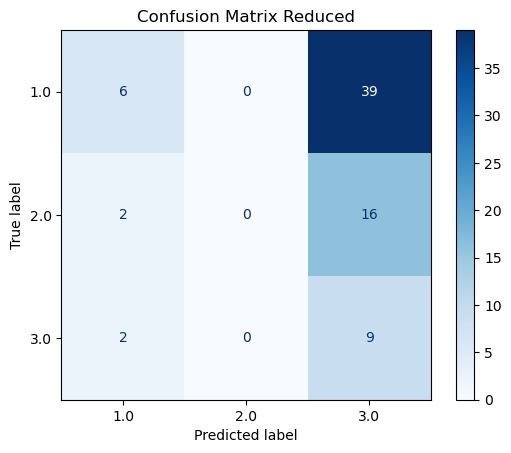

In [5]:
cm = confusion_matrix(y_test, y_pred)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

cm_display.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


cm_reduced = confusion_matrix(
    y_test_reduced,
    y_pred_reduced
)

cm_display_reduced = ConfusionMatrixDisplay(
    confusion_matrix=cm_reduced,
    display_labels=classes_reduced
)

cm_display_reduced.plot(cmap='Blues')

plt.title("Confusion Matrix Reduced")
plt.grid(False)
plt.show()